In [1]:
# ----------------------------------------------------------------
# Part A Setup
# ----------------------------------------------------------------

import os
import re
import string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from nltk.stem import PorterStemmer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Make results more stable
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# ----------------------------------------------------------------
# L1: Data Loading with String Handling
# ----------------------------------------------------------------

print("----- Loading Train and Validation Data -----")

def find_data_file(filename):
    """Find the dataset file from common locations."""
    candidates = [
        Path("data") / filename,
        Path(filename),
        Path("dataset") / filename,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Cannot find {filename}. Put it in data/{filename} or the same folder as this notebook."
    )


def load_emotion_file(path):
    """
    Load a txt file where each line looks like:
    sentence text;emotion_label
    """
    texts = []
    labels = []

    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()          # L1: remove beginning/end spaces

            if line == "":              # L1: skip empty lines
                continue

            # Use rsplit so only the final semicolon separates text and label
            text, label = line.rsplit(";", 1)
            texts.append(text.strip())
            labels.append(label.strip())

    return pd.DataFrame({
        "text": texts,
        "emotion": labels
    })

# Important: only load train and validation here.
# Test data is loaded only in the final evaluation section.
train_df = load_emotion_file(find_data_file("train.txt"))
val_df = load_emotion_file(find_data_file("val.txt"))

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nFirst 5 training rows:")
display(train_df.head())

----- Loading Train and Validation Data -----
Train shape: (16000, 2)
Validation shape: (2000, 2)

First 5 training rows:


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [3]:
# Check class balance using train and validation only

print("Training emotion counts:")
print(train_df["emotion"].value_counts())

print("\nValidation emotion counts:")
print(val_df["emotion"].value_counts())

Training emotion counts:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Validation emotion counts:
emotion
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64


In [4]:
# ----------------------------------------------------------------
# L2: Text Cleaning and Preprocessing
# ----------------------------------------------------------------

print("----- Cleaning Text -----")

stemmer = PorterStemmer()

def clean_text(text):
    """Clean text using basic L1-L2 preprocessing."""
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 3. Remove numbers
    text = re.sub(r"\d+", " ", text)

    # 4. Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 5. Tokenization using split()
    words = text.split()

    # 6. Remove common stopwords and use stemming
    cleaned_words = []
    for word in words:
        if word not in ENGLISH_STOP_WORDS:
            cleaned_words.append(stemmer.stem(word))

    return " ".join(cleaned_words)

# Apply cleaning to train and validation only
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)

print("Before cleaning:")
print(train_df["text"].iloc[0])

print("\nAfter cleaning:")
print(train_df["clean_text"].iloc[0])

----- Cleaning Text -----
Before cleaning:
i didnt feel humiliated

After cleaning:
didnt feel humili


In [5]:
# ----------------------------------------------------------------
# L3: Text Representation with TF-IDF
# ----------------------------------------------------------------

print("----- TF-IDF Vectorization -----")

tfidf = TfidfVectorizer(max_features=5000)

# Important:
# fit_transform is ONLY for training data.
# transform is used for validation data.
X_train = tfidf.fit_transform(train_df["clean_text"]).toarray()
X_val = tfidf.transform(val_df["clean_text"]).toarray()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

----- TF-IDF Vectorization -----
X_train shape: (16000, 5000)
X_val shape: (2000, 5000)


In [6]:
# ----------------------------------------------------------------
# Prepare Target Variable Y
# ----------------------------------------------------------------

print("----- Preparing Labels -----")

# Use the class order learned from the training set.
# This avoids using test labels to decide anything.
emotion_order = sorted(train_df["emotion"].unique())
print("Emotion order:", emotion_order)

train_df["emotion"] = pd.Categorical(train_df["emotion"], categories=emotion_order)
val_df["emotion"] = pd.Categorical(val_df["emotion"], categories=emotion_order)

y_train_df = pd.get_dummies(train_df["emotion"]).astype(int)
y_val_df = pd.get_dummies(val_df["emotion"]).astype(int)

y_train = y_train_df.values
y_val = y_val_df.values

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("\nFirst 5 y_train rows:")
print(y_train[:5])

----- Preparing Labels -----
Emotion order: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
y_train shape: (16000, 6)
y_val shape: (2000, 6)

First 5 y_train rows:
[[0 0 0 0 1 0]
 [0 0 0 0 1 0]
 [1 0 0 0 0 0]
 [0 0 0 1 0 0]
 [1 0 0 0 0 0]]


In [7]:
# ----------------------------------------------------------------
# L4: Build a Basic Dense Neural Network
# ----------------------------------------------------------------

print("----- Building Part A Baseline Model -----")

num_classes = len(emotion_order)
input_size = X_train.shape[1]

part_a_model = Sequential([
    Input(shape=(input_size,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

part_a_model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

part_a_model.summary()

----- Building Part A Baseline Model -----


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,774 (2.47 MB)

 Trainable params: 648,774 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ----------------------------------------------------------------
# L5: Train on Train Data and Validate on Validation Data
# ----------------------------------------------------------------

print("----- Training Part A Baseline Model -----")

part_a_history = part_a_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

----- Training Part A Baseline Model -----
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6194 - loss: 1.0381 - val_accuracy: 0.8405 - val_loss: 0.4731
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8783 - loss: 0.3614 - val_accuracy: 0.8485 - val_loss: 0.4141
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9279 - loss: 0.2171 - val_accuracy: 0.8415 - val_loss: 0.4509
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9484 - loss: 0.1576 - val_accuracy: 0.8400 - val_loss: 0.4945
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9612 - loss: 0.1198 - val_accuracy: 0.8345 - val_loss: 0.5358
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9710 - loss: 0.0916 - val_accuracy: 0.8320 - val_loss: 0.5804
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9779 - loss: 0.0701 - val_accuracy: 0.8250 - val_loss: 0.6247
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accurac

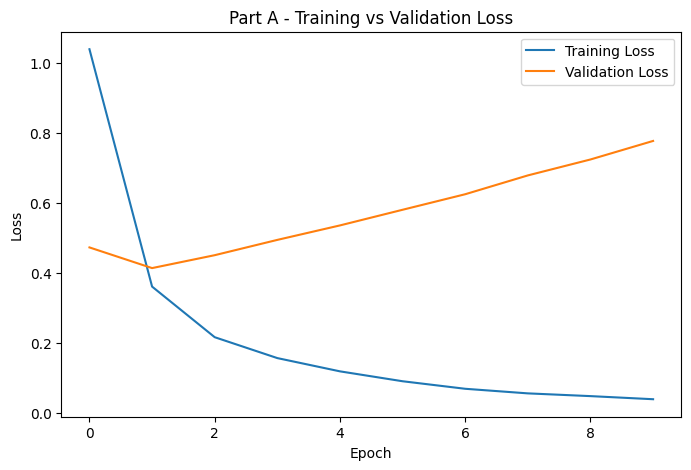

In [9]:
# ----------------------------------------------------------------
# L5: Plot Training and Validation Loss
# ----------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(part_a_history.history["loss"], label="Training Loss")
plt.plot(part_a_history.history["val_loss"], label="Validation Loss")
plt.title("Part A - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

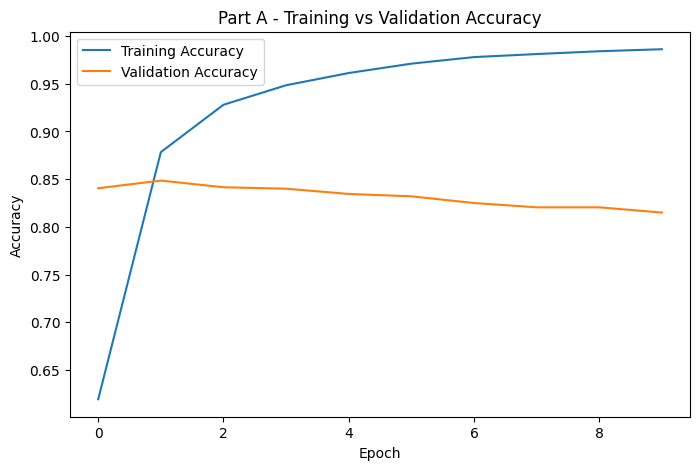

In [10]:
# ----------------------------------------------------------------
# L5: Plot Training and Validation Accuracy
# ----------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(part_a_history.history["accuracy"], label="Training Accuracy")
plt.plot(part_a_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Part A - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [11]:
# ----------------------------------------------------------------
# L5: Validation Evaluation
# ----------------------------------------------------------------

print("----- Part A Validation Evaluation -----")

val_pred_prob = part_a_model.predict(X_val)
val_pred = np.argmax(val_pred_prob, axis=1)
val_true = np.argmax(y_val, axis=1)

print("Validation Accuracy:", accuracy_score(val_true, val_pred))
print("\nValidation Classification Report:")
print(classification_report(
    val_true,
    val_pred,
    labels=list(range(num_classes)),
    target_names=emotion_order,
    zero_division=0
))

----- Part A Validation Evaluation -----
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Validation Accuracy: 0.815

Validation Classification Report:
              precision    recall  f1-score   support

       anger       0.79      0.85      0.82       275
        fear       0.76      0.81      0.79       212
         joy       0.86      0.83      0.84       704
        love       0.68      0.66      0.67       178
     sadness       0.85      0.84      0.85       550
    surprise       0.73      0.72      0.72        81

    accuracy                           0.81      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.82      0.81      0.82      2000



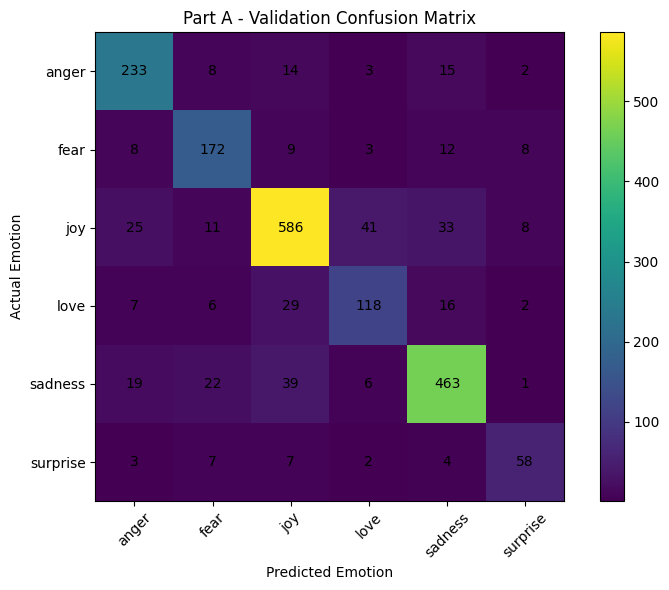

In [12]:
# Validation confusion matrix

val_cm = confusion_matrix(val_true, val_pred, labels=list(range(num_classes)))

plt.figure(figsize=(8, 6))
plt.imshow(val_cm)
plt.title("Part A - Validation Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.xticks(np.arange(num_classes), emotion_order, rotation=45)
plt.yticks(np.arange(num_classes), emotion_order)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, val_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [13]:
# ----------------------------------------------------------------
# Part A Prediction Function for New Unseen Text
# ----------------------------------------------------------------

print("----- Part A Live Prediction Function -----")

def predict_emotion_part_a(raw_text):
    cleaned = clean_text(raw_text)
    vectorized = tfidf.transform([cleaned]).toarray()
    prediction_prob = part_a_model.predict(vectorized, verbose=0)
    prediction_index = np.argmax(prediction_prob, axis=1)[0]
    predicted_emotion = emotion_order[prediction_index]

    print("Original Text:", raw_text)
    print("Cleaned Text:", cleaned)
    print("Predicted Emotion:", predicted_emotion)

    return predicted_emotion

predict_emotion_part_a("I feel very happy and excited today!")

----- Part A Live Prediction Function -----
Original Text: I feel very happy and excited today!
Cleaned Text: feel happi excit today
Predicted Emotion: joy


'joy'

In [14]:
# ----------------------------------------------------------------
# Part B Setup
# ----------------------------------------------------------------

print("----- Part B: Pretrained GloVe Embeddings + BiLSTM -----")

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    SpatialDropout1D,
    GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

----- Part B: Pretrained GloVe Embeddings + BiLSTM -----


In [15]:
# ----------------------------------------------------------------
# Light Cleaning for Pretrained Embeddings
# ----------------------------------------------------------------

print("----- Light Cleaning for GloVe -----")

def light_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#[a-zA-Z0-9_]+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Again: train and validation only here. Test is still not used.
train_df["glove_text"] = train_df["text"].apply(light_clean_text)
val_df["glove_text"] = val_df["text"].apply(light_clean_text)

print("Before cleaning:")
print(train_df["text"].iloc[0])

print("\nAfter light cleaning:")
print(train_df["glove_text"].iloc[0])

----- Light Cleaning for GloVe -----
Before cleaning:
i didnt feel humiliated

After light cleaning:
i didnt feel humiliated


In [16]:
# ----------------------------------------------------------------
# Tokenization and Padding
# ----------------------------------------------------------------

print("----- Tokenization and Padding -----")

max_words = 15000
max_len = 60

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Important: fit ONLY on training text.
tokenizer.fit_on_texts(train_df["glove_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["glove_text"])
X_val_seq = tokenizer.texts_to_sequences(val_df["glove_text"])

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Vocabulary size:", len(tokenizer.word_index))
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)

----- Tokenization and Padding -----
Vocabulary size: 15210
X_train_pad shape: (16000, 60)
X_val_pad shape: (2000, 60)


In [17]:
# ----------------------------------------------------------------
# Load Pretrained GloVe Embeddings
# ----------------------------------------------------------------

print("----- Loading GloVe Embeddings -----")

embedding_dim = 100
possible_glove_paths = [
    Path("data") / "glove.6B.100d.txt",
    Path("glove.6B.100d.txt"),
    Path("embeddings") / "glove.6B.100d.txt",
]

glove_path = None
for path in possible_glove_paths:
    if path.exists():
        glove_path = path
        break

if glove_path is None:
    raise FileNotFoundError(
        "GloVe file not found. Please place glove.6B.100d.txt in the same folder as this notebook, "
        "or inside data/ or embeddings/."
    )

print("Using GloVe file:", glove_path)

embeddings_index = {}

with open(glove_path, encoding="utf-8") as file:
    for line in file:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Total GloVe word vectors loaded:", len(embeddings_index))

----- Loading GloVe Embeddings -----
Using GloVe file: data\glove.6B.100d.txt
Total GloVe word vectors loaded: 400000


In [18]:
# ----------------------------------------------------------------
# Create Embedding Matrix
# ----------------------------------------------------------------

print("----- Creating Embedding Matrix -----")

word_index = tokenizer.word_index
num_words = min(max_words, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, embedding_dim))
matched_words = 0

for word, i in word_index.items():
    if i >= max_words:
        continue

    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        matched_words += 1

coverage = matched_words / num_words * 100

print("Words in tokenizer:", len(word_index))
print("Words used in embedding matrix:", num_words)
print("Words matched with GloVe:", matched_words)
print(f"GloVe coverage: {coverage:.2f}%")
print("Embedding matrix shape:", embedding_matrix.shape)

----- Creating Embedding Matrix -----
Words in tokenizer: 15210
Words used in embedding matrix: 15000
Words matched with GloVe: 14026
GloVe coverage: 93.51%
Embedding matrix shape: (15000, 100)


In [19]:
# ----------------------------------------------------------------
# Build GloVe + BiLSTM Model
# ----------------------------------------------------------------

print("----- Building GloVe + BiLSTM Model -----")

part_b_model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False,
        name="pretrained_glove_embedding"
    ),

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(
        64,
        return_sequences=True,
        dropout=0.2
    )),

    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

part_b_model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

part_b_model.summary()

----- Building GloVe + BiLSTM Model -----


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_glove_embedding      │ (None, 60, 100)        │     1,500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593,126 (6.08 MB)

 Trainable params: 93,126 (363.77 KB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [20]:
# ----------------------------------------------------------------
# Train the GloVe + BiLSTM Model
# ----------------------------------------------------------------

print("----- Training Part B Model -----")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

part_b_history = part_b_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

----- Training Part B Model -----
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3893 - loss: 1.5397 - val_accuracy: 0.5300 - val_loss: 1.2259 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5706 - loss: 1.1914 - val_accuracy: 0.7000 - val_loss: 0.8642 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6468 - loss: 0.9786 - val_accuracy: 0.7640 - val_loss: 0.6632 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6892 - loss: 0.8618 - val_accuracy: 0.8125 - val_loss: 0.5330 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7237 - loss: 0.7676 - val_accuracy: 0.8450 - val_loss: 0.4480 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7509 - loss: 0.6907 - val_accuracy: 0.8650 - val_loss: 0.3672 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/

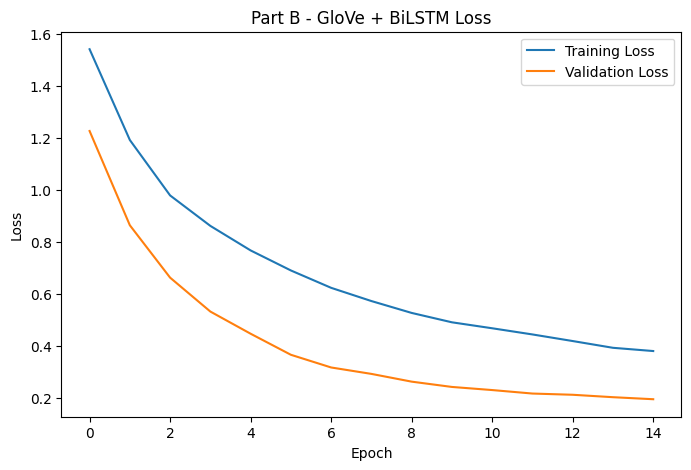

In [21]:
# ----------------------------------------------------------------
# Plot Part B Training and Validation Loss
# ----------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(part_b_history.history["loss"], label="Training Loss")
plt.plot(part_b_history.history["val_loss"], label="Validation Loss")
plt.title("Part B - GloVe + BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

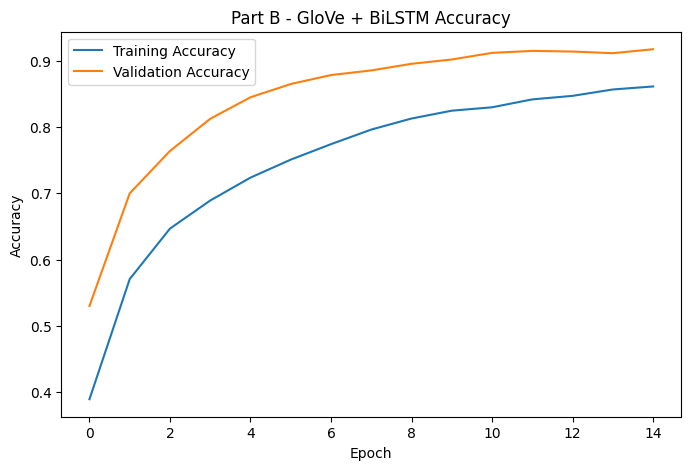

In [22]:
# ----------------------------------------------------------------
# Plot Part B Training and Validation Accuracy
# ----------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(part_b_history.history["accuracy"], label="Training Accuracy")
plt.plot(part_b_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Part B - GloVe + BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [23]:
# ----------------------------------------------------------------
# Part B Validation Evaluation
# ----------------------------------------------------------------

print("----- Part B Validation Evaluation -----")

b_val_pred_prob = part_b_model.predict(X_val_pad)
b_val_pred = np.argmax(b_val_pred_prob, axis=1)

print("Validation Accuracy:", accuracy_score(val_true, b_val_pred))
print("\nValidation Classification Report:")
print(classification_report(
    val_true,
    b_val_pred,
    labels=list(range(num_classes)),
    target_names=emotion_order,
    zero_division=0
))

----- Part B Validation Evaluation -----
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Validation Accuracy: 0.9175

Validation Classification Report:
              precision    recall  f1-score   support

       anger       0.90      0.91      0.90       275
        fear       0.87      0.89      0.88       212
         joy       0.95      0.93      0.94       704
        love       0.85      0.88      0.86       178
     sadness       0.94      0.96      0.95       550
    surprise       0.90      0.74      0.81        81

    accuracy                           0.92      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000



In [24]:
# ----------------------------------------------------------------
# Load Test Data Only Now
# ----------------------------------------------------------------

print("----- Loading Test Data for Final Evaluation Only -----")

test_df = load_emotion_file(find_data_file("test.txt"))
print("Test shape:", test_df.shape)

# Clean test text using the already-created Part A cleaning function
# This is allowed because the function is fixed before seeing test results.
test_df["clean_text"] = test_df["text"].apply(clean_text)

# Important: use transform only. Do not fit on test.
X_test = tfidf.transform(test_df["clean_text"]).toarray()

# Prepare y_test using the training emotion order
test_df["emotion"] = pd.Categorical(test_df["emotion"], categories=emotion_order)
y_test_df = pd.get_dummies(test_df["emotion"]).astype(int)
y_test = y_test_df.values

test_true = np.argmax(y_test, axis=1)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

----- Loading Test Data for Final Evaluation Only -----
Test shape: (2000, 2)
X_test shape: (2000, 5000)
y_test shape: (2000, 6)


In [25]:
# ----------------------------------------------------------------
# Final Test Evaluation for Part A
# ----------------------------------------------------------------

print("----- Final Test Evaluation: Part A -----")

part_a_test_loss, part_a_test_acc = part_a_model.evaluate(X_test, y_test, verbose=0)
part_a_test_pred_prob = part_a_model.predict(X_test)
part_a_test_pred = np.argmax(part_a_test_pred_prob, axis=1)

print("Part A Test Loss:", part_a_test_loss)
print("Part A Test Accuracy:", part_a_test_acc)
print("\nPart A Test Classification Report:")
print(classification_report(
    test_true,
    part_a_test_pred,
    labels=list(range(num_classes)),
    target_names=emotion_order,
    zero_division=0
))

----- Final Test Evaluation: Part A -----
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Part A Test Loss: 0.7480651140213013
Part A Test Accuracy: 0.8274999856948853

Part A Test Classification Report:
              precision    recall  f1-score   support

       anger       0.78      0.86      0.82       275
        fear       0.78      0.83      0.80       224
         joy       0.86      0.85      0.86       695
        love       0.64      0.66      0.65       159
     sadness       0.90      0.85      0.87       581
    surprise       0.71      0.68      0.70        66

    accuracy                           0.83      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.83      0.83      0.83      2000



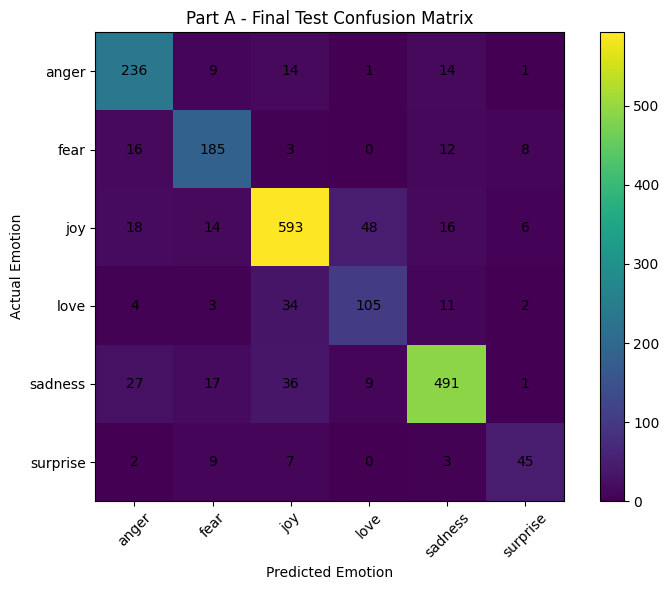

In [26]:
# Part A final test confusion matrix

part_a_test_cm = confusion_matrix(test_true, part_a_test_pred, labels=list(range(num_classes)))

plt.figure(figsize=(8, 6))
plt.imshow(part_a_test_cm)
plt.title("Part A - Final Test Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.xticks(np.arange(num_classes), emotion_order, rotation=45)
plt.yticks(np.arange(num_classes), emotion_order)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, part_a_test_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [27]:
# ----------------------------------------------------------------
# Prepare Test Data for Part B
# ----------------------------------------------------------------

print("----- Preparing Test Data for Part B -----")

# Light clean test text with the fixed Part B cleaning function
test_df["glove_text"] = test_df["text"].apply(light_clean_text)

# Important: use the existing tokenizer. Do not fit on test.
X_test_seq = tokenizer.texts_to_sequences(test_df["glove_text"])
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("X_test_pad shape:", X_test_pad.shape)

----- Preparing Test Data for Part B -----
X_test_pad shape: (2000, 60)


In [28]:
# ----------------------------------------------------------------
# Final Test Evaluation for Part B
# ----------------------------------------------------------------

print("----- Final Test Evaluation: Part B -----")

part_b_test_loss, part_b_test_acc = part_b_model.evaluate(X_test_pad, y_test, verbose=0)
part_b_test_pred_prob = part_b_model.predict(X_test_pad)
part_b_test_pred = np.argmax(part_b_test_pred_prob, axis=1)

print("Part B Test Loss:", part_b_test_loss)
print("Part B Test Accuracy:", part_b_test_acc)
print("\nPart B Test Classification Report:")
print(classification_report(
    test_true,
    part_b_test_pred,
    labels=list(range(num_classes)),
    target_names=emotion_order,
    zero_division=0
))

----- Final Test Evaluation: Part B -----
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Part B Test Loss: 0.19072212278842926
Part B Test Accuracy: 0.9190000295639038

Part B Test Classification Report:
              precision    recall  f1-score   support

       anger       0.92      0.91      0.92       275
        fear       0.86      0.91      0.88       224
         joy       0.94      0.94      0.94       695
        love       0.80      0.84      0.82       159
     sadness       0.95      0.96      0.96       581
    surprise       0.82      0.62      0.71        66

    accuracy                           0.92      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.92      0.92      0.92      2000



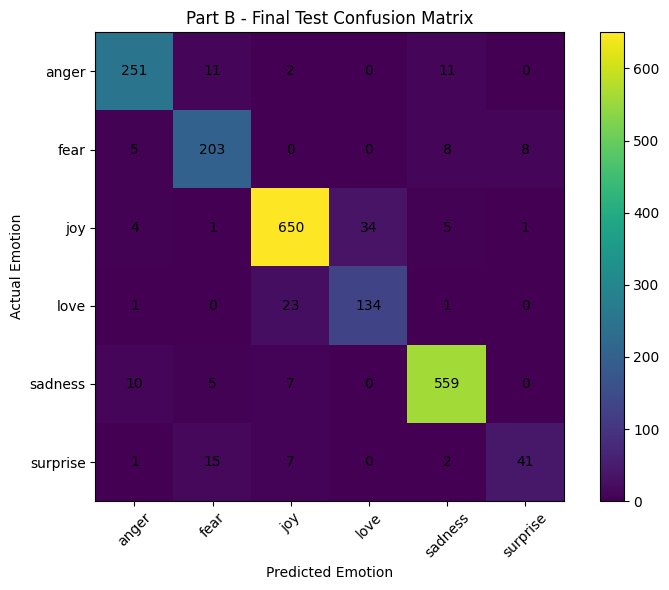

In [29]:
# Part B final test confusion matrix

part_b_test_cm = confusion_matrix(test_true, part_b_test_pred, labels=list(range(num_classes)))

plt.figure(figsize=(8, 6))
plt.imshow(part_b_test_cm)
plt.title("Part B - Final Test Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.xticks(np.arange(num_classes), emotion_order, rotation=45)
plt.yticks(np.arange(num_classes), emotion_order)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, part_b_test_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [30]:
# ----------------------------------------------------------------
# Compare Part A and Part B Final Test Results
# ----------------------------------------------------------------

comparison_df = pd.DataFrame({
    "Model": ["Part A: TF-IDF + Dense NN", "Part B: GloVe + BiLSTM"],
    "Test Loss": [part_a_test_loss, part_b_test_loss],
    "Test Accuracy": [part_a_test_acc, part_b_test_acc]
})

comparison_df

,Model,Test Loss,Test Accuracy
0,Part A: TF-IDF + Dense NN,0.748065,0.8275
1,Part B: GloVe + BiLSTM,0.190722,0.9190


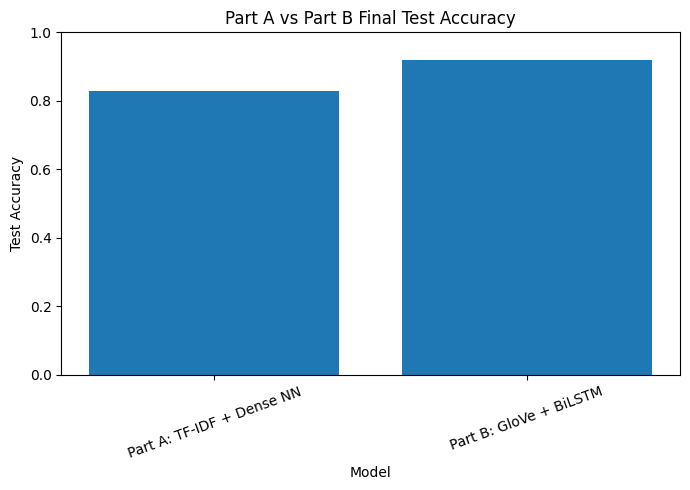

In [31]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Part A vs Part B Final Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------
# Part B Prediction Function for New Unseen Text
# ----------------------------------------------------------------

print("----- Part B Live Prediction Function -----")

def predict_emotion_part_b(raw_text):
    cleaned = light_clean_text(raw_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )
    prediction_prob = part_b_model.predict(padded, verbose=0)
    prediction_index = np.argmax(prediction_prob, axis=1)[0]
    predicted_emotion = emotion_order[prediction_index]

    print("Original Text:", raw_text)
    print("Cleaned Text:", cleaned)
    print("Predicted Emotion:", predicted_emotion)

    return predicted_emotion

predict_emotion_part_b("I cannot believe this happened, I am shocked!")

----- Part B Live Prediction Function -----
Original Text: I cannot believe this happened, I am shocked!
Cleaned Text: i cannot believe this happened i am shocked
Predicted Emotion: surprise


'surprise'

: 